# Do Communication Apprehension Scores Predict Regular Public Transit Use?

### A Random Forest evaluation of group & interpersonal PRCA as predictors of weekly+ ridership

**Course:** PSYCH 755 · University of Wisconsin–Madison  
**Project:** CA persona / PRCA research framework  
**Notebook role:** Secondary research question — psychological predictors of transit behavior  

---

#### Research question

> Among Prolific↔Qualtrics **matched** respondents with complete PRCA ground truth, do **group** and **interpersonal** communication-apprehension scores predict whether an individual takes **public transportation regularly**?

| Element | Specification |
|---|---|
| **Outcome** | `regular_transit`: `Q26` ∈ {`4-8 days a month`, `8 or more days a month`} |
| **Features** | `gt_group_ca`, `gt_interpersonal_ca` (PRCA subscales, range 6–30) |
| **Model** | Balanced Random Forest + stratified 5-fold CV |
| **Comparisons** | Chance baseline; group-only RF; interpersonal-only RF |

This notebook pairs with the written interpretation in [`docs/secondary_rq_ca_predicts_transit.md`](../docs/secondary_rq_ca_predicts_transit.md).


## 1. Analytic roadmap

| Section | Content |
|---|---|
| **2. Setup** | Imports, paths, presentation styling |
| **3. Sample** | Matched File A/B/C cohort; outcome definition |
| **4. Descriptive associations** | Mean CA by transit group; point-biserial correlations |
| **5. Model** | Random Forest specification & baselines |
| **6. CV performance** | ROC-AUC, PR-AUC, F1, confusion matrix |
| **7. Interpretation aids** | Importances; CA-plane probability surface |
| **8. Written results** | Plain-language findings for slides / manuscript |
| **9. Artifacts & limitations** | Export package + caveats |

Supporting code: [`src/ca_personas/ca_transit_rf.py`](../src/ca_personas/ca_transit_rf.py)


## 2. Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ca_personas.ca_transit_rf import (
    CA_FEATURES,
    run_ca_transit_rf_analysis,
    save_ca_transit_rf_artifacts,
)
from ca_personas.load import load_full_cohort
from ca_personas.paths import (
    cohort_source_label,
    default_prolific_paths,
    default_qualtrics_path,
    sibling_data_available,
)
from ca_personas.transit_ca import PRIMARY_REGULAR_LABELS, Q26_STEM

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})
COLOR_REGULAR = "#C5050C"
COLOR_NOT = "#3D3D3D"
COLOR_ACCENT = "#047A9C"
COLOR_GROUP = "#8B1E3F"
COLOR_INTERP = "#1F4E79"

OUT = ROOT / "outputs" / "ca_transit_rf"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

assert sibling_data_available(), (
    "Place File A/B/C under ../sibling_data/ (or /tmp/sibling_data) before running."
)
data_source = cohort_source_label()
assert "excerpt" not in data_source.lower()
print("Data source:", data_source)
print("Prolific:", [str(p) for p in default_prolific_paths()])
print("Qualtrics:", default_qualtrics_path())
print("Features:", CA_FEATURES)
print("Regular labels:", sorted(PRIMARY_REGULAR_LABELS))
print("Q26 stem:", Q26_STEM)


Data source: /tmp/sibling_data File A/B/C
Prolific: ['/tmp/sibling_data/PRCAProlificExport_FileA.csv', '/tmp/sibling_data/PRCAProlificExport_FileB.csv']
Qualtrics: /tmp/sibling_data/PRCAQualtricsExport_FileC.csv
Features: ['gt_group_ca', 'gt_interpersonal_ca']
Regular labels: ['4-8 days a month', '8 or more days a month']
Q26 stem: In the last three months on how many days did you use public transportation (bus, train, tram, etc.)?


## 3. Data & sample

**Inclusion:** stacked Prolific File A + File B inner-joined to Qualtrics File C on `Q0` / `Participant id`, complete PRCA group + interpersonal items, non-missing `Q26`.


In [2]:
participants, cleaning_report = load_full_cohort(join_how="inner")
analysis = run_ca_transit_rf_analysis(
    participants,
    n_splits=5,
    n_perm_repeats=30,
    random_state=42,
    grid_size=70,
)
frame = analysis["frame"]
summary = analysis["summary"]

print(json.dumps({
    "n_analytic": cleaning_report["n_analytic"],
    "modeling_n": summary["sample"]["n"],
    "n_regular": summary["sample"]["n_regular"],
    "n_not_regular": summary["sample"]["n_not_regular"],
    "prevalence": summary["sample"]["prevalence"],
}, indent=2))
frame.head()


{
  "n_analytic": 241,
  "modeling_n": 241,
  "n_regular": 101,
  "n_not_regular": 140,
  "prevalence": 0.4190871369294606
}


,participant_id,gt_group_ca,gt_interpersonal_ca,regular_transit,transit_group,Q26,gt_group_band,gt_interpersonal_band,Age,Sex,Country of residence,Employment status,Student status,y
0,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496...,14,16,False,not_regular,2-4 days a month,moderate,moderate,36.0000,Male,United States,Part-Time,Yes,0
1,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449...,17,17,False,not_regular,Never,moderate,moderate,41.0000,Male,United States,Other,No,0
2,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e...,11,12,False,not_regular,Never,low,low,39.0000,Male,United States,Full-Time,No,0
3,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d21...,10,6,False,not_regular,Never,low,low,61.0000,Male,United Kingdom,Other,No,0
4,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e0...,8,12,False,not_regular,Never,low,low,45.0000,Male,United States,Full-Time,No,0


## 4. Descriptive associations

Before modeling, we ask whether regular riders already differ in mean CA (the same contrast tested inferentially in `secondary_rq_transit_ca.ipynb`) and how strongly each subscale correlates with the binary outcome.


In [3]:
analysis["descriptives"]


,group,n,mean_gt_group_ca,std_gt_group_ca,median_gt_group_ca,mean_gt_interpersonal_ca,std_gt_interpersonal_ca,median_gt_interpersonal_ca
0,overall,241,14.6224,6.0328,13.0000,14.3112,5.8180,13.0000
1,regular,101,13.0396,5.0772,12.0000,13.3069,5.3661,13.0000
2,not_regular,140,15.7643,6.4156,14.0000,15.0357,6.0387,14.0000


In [4]:
assoc = analysis["associations"]
assoc


,feature,point_biserial_r,p_value,mean_regular,mean_not_regular,diff_regular_minus_not
0,gt_group_ca,-0.2233,0.0005,13.0396,15.7643,-2.7247
1,gt_interpersonal_ca,-0.1469,0.0225,13.3069,15.0357,-1.7288


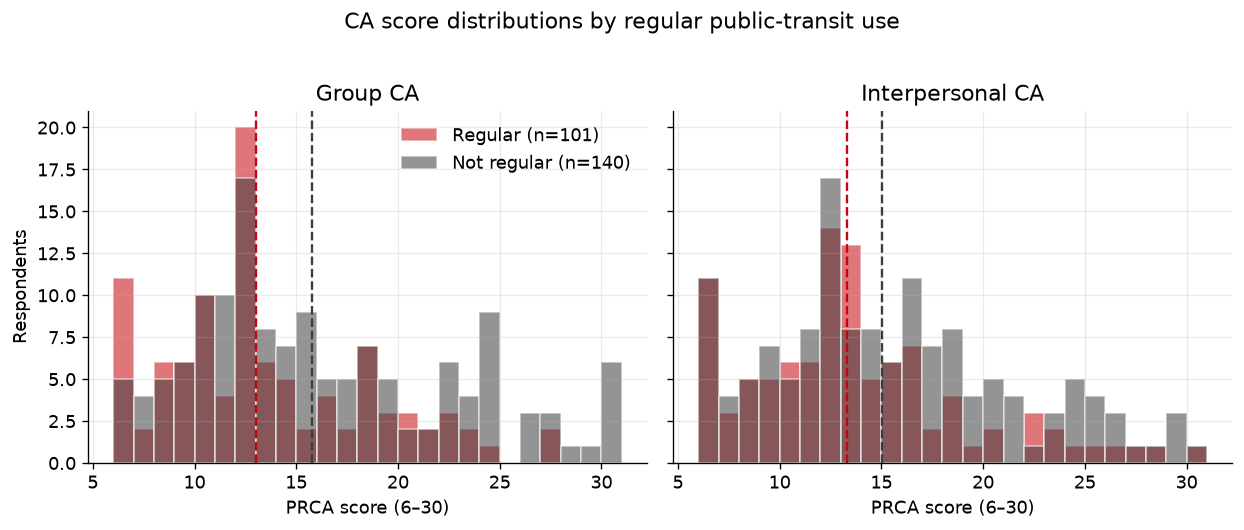

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), sharey=True)
for ax, col, title, color in zip(
    axes,
    ["gt_group_ca", "gt_interpersonal_ca"],
    ["Group CA", "Interpersonal CA"],
    [COLOR_GROUP, COLOR_INTERP],
):
    for group, gcolor, label in [
        ("regular", COLOR_REGULAR, "Regular"),
        ("not_regular", COLOR_NOT, "Not regular"),
    ]:
        vals = frame.loc[frame["transit_group"] == group, col]
        ax.hist(vals, bins=range(6, 32), alpha=0.55, color=gcolor if group=="regular" else COLOR_NOT,
                label=f"{label} (n={len(vals)})", edgecolor="white")
        ax.axvline(vals.mean(), color=gcolor if group=="regular" else COLOR_NOT, ls="--", lw=1.4)
    ax.set_title(title)
    ax.set_xlabel("PRCA score (6–30)")
axes[0].set_ylabel("Respondents")
axes[0].legend()
fig.suptitle("CA score distributions by regular public-transit use", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "fig_ca_dist_by_transit.png", bbox_inches="tight")
plt.show()


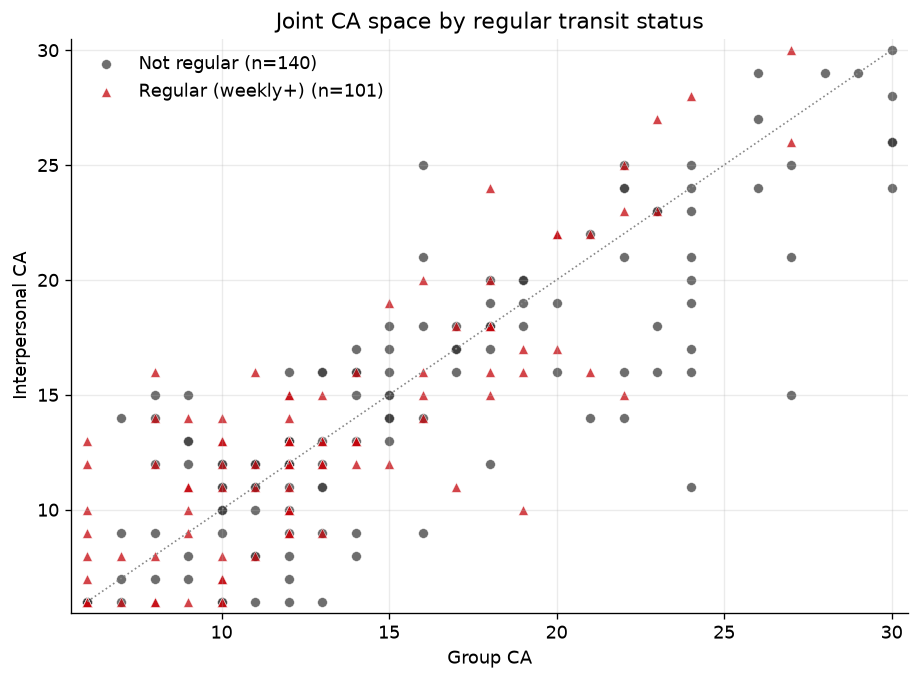

In [6]:
fig, ax = plt.subplots(figsize=(7.8, 5.8))
for group, color, marker, label in [
    ("not_regular", COLOR_NOT, "o", "Not regular"),
    ("regular", COLOR_REGULAR, "^", "Regular (weekly+)"),
]:
    sub = frame.loc[frame["transit_group"] == group]
    ax.scatter(
        sub["gt_group_ca"], sub["gt_interpersonal_ca"],
        s=34, alpha=0.75, c=color, marker=marker,
        edgecolors="white", linewidths=0.35,
        label=f"{label} (n={len(sub)})",
    )
ax.plot([6, 30], [6, 30], ls=":", color="#888888", lw=1)
ax.set_xlim(5.5, 30.5); ax.set_ylim(5.5, 30.5)
ax.set_xlabel("Group CA")
ax.set_ylabel("Interpersonal CA")
ax.set_title("Joint CA space by regular transit status")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "fig_ca_joint_by_transit.png", bbox_inches="tight")
plt.show()


## 5. Model specification

- **Primary RF:** both `gt_group_ca` and `gt_interpersonal_ca` (z-scored), 500 trees, `class_weight="balanced"`, `min_samples_leaf=3`
- **Ablations:** group-only RF; interpersonal-only RF  
- **Null:** prevalence / majority baselines (ROC-AUC = 0.5 for constant scores)


In [7]:
print("Primary features:", CA_FEATURES)
analysis["metrics_table"][[
    "model", "n", "roc_auc", "average_precision",
    "balanced_accuracy", "accuracy", "precision", "recall", "f1", "brier"
]]


Primary features: ['gt_group_ca', 'gt_interpersonal_ca']


,model,n,roc_auc,average_precision,balanced_accuracy,accuracy,precision,recall,f1,brier
0,random_forest_group_and_interpersonal,241,0.5897,0.4828,0.5734,0.5685,0.4880,0.6040,0.5398,0.2520
1,random_forest_group_only,241,0.5548,0.4500,0.5575,0.5436,0.4676,0.6436,0.5417,0.2667
2,random_forest_interpersonal_only,241,0.5065,0.4249,0.5047,0.5062,0.4237,0.4950,0.4566,0.2697
3,prevalence_prob,241,0.5000,0.4191,0.5000,0.5809,0.0000,0.0000,0.0000,0.2435
4,majority_class,241,0.5000,0.4191,0.5000,0.5809,0.0000,0.0000,0.0000,0.4191


## 6. Cross-validated predictive performance


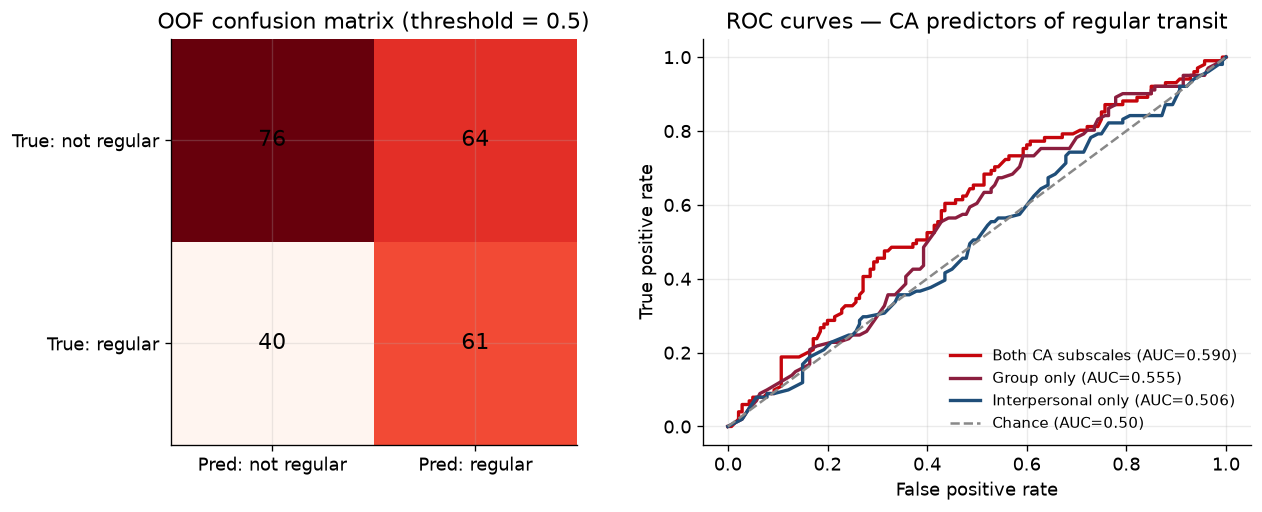

In [8]:
rf_m = summary["cv_metrics"]
cm = np.array([[rf_m["tn"], rf_m["fp"]], [rf_m["fn"], rf_m["tp"]],], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax = axes[0]
ax.imshow(cm, cmap="Reds")
ax.set_xticks([0, 1], ["Pred: not regular", "Pred: regular"])
ax.set_yticks([0, 1], ["True: not regular", "True: regular"])
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=13)
ax.set_title("OOF confusion matrix (threshold = 0.5)")

ax = axes[1]
for key, color, label in [
    ("roc", COLOR_REGULAR, f"Both CA subscales (AUC={rf_m['roc_auc']:.3f})"),
    ("roc_group_only", COLOR_GROUP, f"Group only (AUC={summary['single_feature_auc']['group_only']:.3f})"),
    ("roc_interpersonal_only", COLOR_INTERP, f"Interpersonal only (AUC={summary['single_feature_auc']['interpersonal_only']:.3f})"),
]:
    roc = analysis[key]
    ax.plot(roc["fpr"], roc["tpr"], color=color, lw=2, label=label)
ax.plot([0, 1], [0, 1], ls="--", color="#888888", label="Chance (AUC=0.50)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — CA predictors of regular transit")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "fig_ca_rf_confusion_roc.png", bbox_inches="tight")
plt.show()


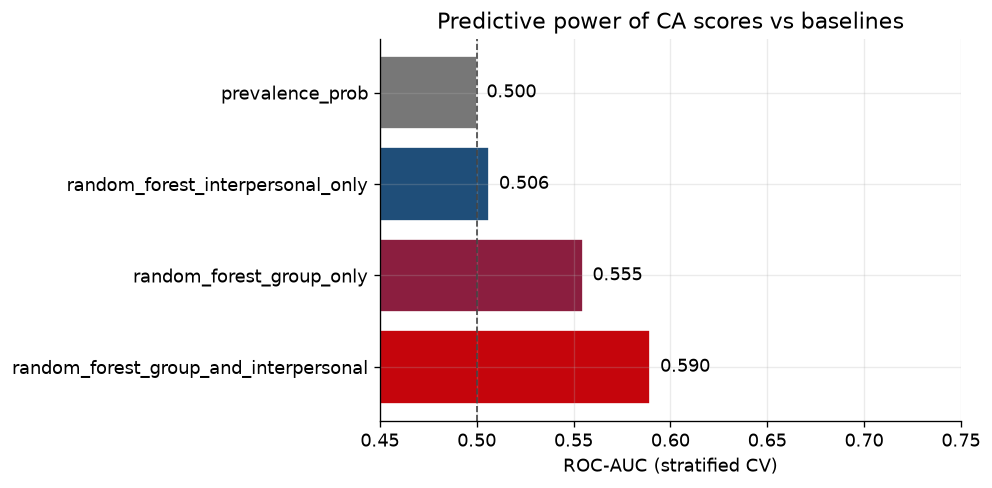

In [9]:
plot_order = [
    "random_forest_group_and_interpersonal",
    "random_forest_group_only",
    "random_forest_interpersonal_only",
    "prevalence_prob",
]
m = analysis["metrics_table"].set_index("model").loc[plot_order, "roc_auc"]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
colors = [COLOR_REGULAR, COLOR_GROUP, COLOR_INTERP, "#777777"]
bars = ax.barh(range(len(m)), m.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(m)), m.index)
ax.axvline(0.5, color="#444", ls="--", lw=1)
ax.set_xlim(0.45, max(0.75, float(m.max()) + 0.05))
ax.set_xlabel("ROC-AUC (stratified CV)")
ax.set_title("Predictive power of CA scores vs baselines")
for bar, v in zip(bars, m.values):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.3f}", va="center")
fig.tight_layout()
fig.savefig(OUT / "fig_ca_rf_auc_comparison.png", bbox_inches="tight")
plt.show()


## 7. Feature importance & decision surface


In [10]:
imp = analysis["gini_importance"].merge(analysis["permutation_importance"], on="feature")
imp


,feature,importance_gini,importance_perm_mean,importance_perm_std
0,gt_group_ca,0.5543,0.3087,0.0292
1,gt_interpersonal_ca,0.4457,0.2233,0.0316


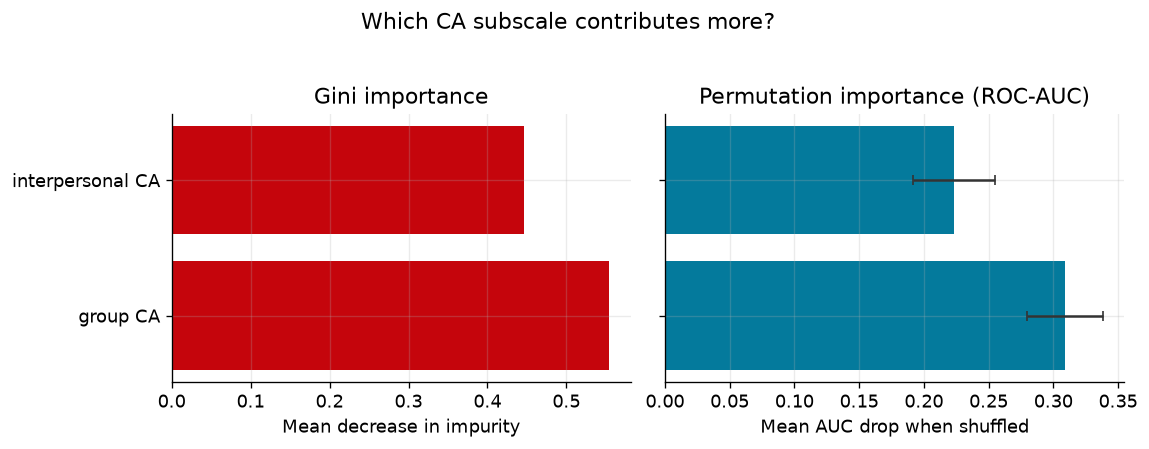

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), sharey=True)
labels = imp["feature"].str.replace("gt_", "").str.replace("_ca", " CA")
axes[0].barh(labels, imp["importance_gini"], color=COLOR_REGULAR)
axes[0].set_title("Gini importance"); axes[0].set_xlabel("Mean decrease in impurity")
axes[1].barh(labels, imp["importance_perm_mean"], xerr=imp["importance_perm_std"],
             color=COLOR_ACCENT, ecolor="#333", capsize=3)
axes[1].set_title("Permutation importance (ROC-AUC)")
axes[1].set_xlabel("Mean AUC drop when shuffled")
fig.suptitle("Which CA subscale contributes more?", y=1.03)
fig.tight_layout()
fig.savefig(OUT / "fig_ca_rf_importance.png", bbox_inches="tight")
plt.show()


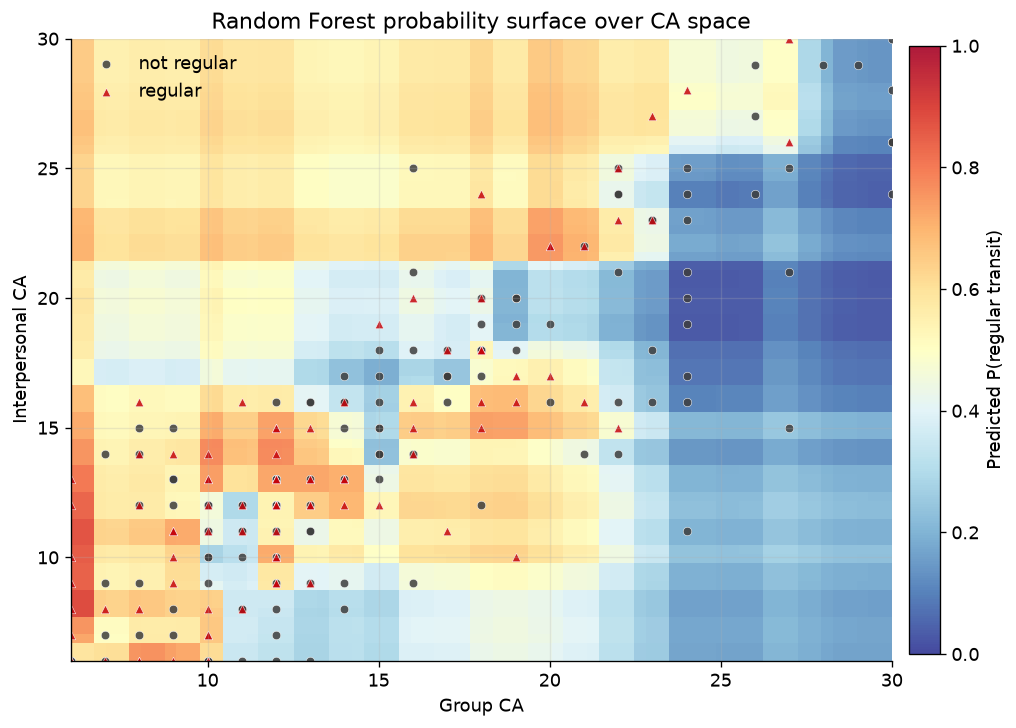

In [12]:
grid = analysis["grid"]
g_vals = np.sort(grid["gt_group_ca"].unique())
i_vals = np.sort(grid["gt_interpersonal_ca"].unique())
Z = grid.pivot(index="gt_interpersonal_ca", columns="gt_group_ca", values="p_regular").values

fig, ax = plt.subplots(figsize=(8.6, 6.2))
im = ax.imshow(
    Z, origin="lower",
    extent=[g_vals.min(), g_vals.max(), i_vals.min(), i_vals.max()],
    aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=1, alpha=0.9,
)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Predicted P(regular transit)")
for group, color, marker in [("not_regular", COLOR_NOT, "o"), ("regular", COLOR_REGULAR, "^")]:
    sub = frame.loc[frame["transit_group"] == group]
    ax.scatter(sub["gt_group_ca"], sub["gt_interpersonal_ca"], s=26, c=color, marker=marker,
               edgecolors="white", linewidths=0.35, alpha=0.85, label=group.replace("_", " "))
ax.set_xlabel("Group CA"); ax.set_ylabel("Interpersonal CA")
ax.set_title("Random Forest probability surface over CA space")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "fig_ca_rf_decision_surface.png", bbox_inches="tight")
plt.show()


## 8. Results write-up (for presentation)

The cell below prints a slide-ready narrative from the live results card. A fuller manuscript-style interpretation lives in [`docs/secondary_rq_ca_predicts_transit.md`](../docs/secondary_rq_ca_predicts_transit.md).


In [13]:
card = summary
assoc = {r["feature"]: r for r in card["associations"]}
g, i = assoc["gt_group_ca"], assoc["gt_interpersonal_ca"]
m = card["cv_metrics"]
print("=" * 72)
print("SECONDARY RQ — CA SCORES → REGULAR PUBLIC TRANSIT")
print("=" * 72)
print(f"Sample: N={card['sample']['n']} matched respondents; "
      f"{card['sample']['n_regular']} regular ({card['sample']['prevalence']:.1%}).")
print()
print("Association (regular vs not-regular):")
print(f"  • Group CA:           M_reg={g['mean_regular']:.2f} vs M_not={g['mean_not_regular']:.2f} "
      f"(Δ={g['diff_regular_minus_not']:+.2f}; r={g['point_biserial_r']:+.3f}; p={g['p_value']:.4f})")
print(f"  • Interpersonal CA:   M_reg={i['mean_regular']:.2f} vs M_not={i['mean_not_regular']:.2f} "
      f"(Δ={i['diff_regular_minus_not']:+.2f}; r={i['point_biserial_r']:+.3f}; p={i['p_value']:.4f})")
print()
print("Random Forest (stratified 5-fold CV):")
print(f"  • Both subscales ROC-AUC = {m['roc_auc']:.3f}")
print(f"  • Group-only AUC        = {card['single_feature_auc']['group_only']:.3f}")
print(f"  • Interpersonal-only    = {card['single_feature_auc']['interpersonal_only']:.3f}")
print(f"  • Chance                = 0.500")
print(f"  • Balanced accuracy     = {m['balanced_accuracy']:.3f}; F1 = {m['f1']:.3f}")
print()
print("Interpretation:")
print(" ", card["verdict"]["interpretation"])
print()
print("Bottom line: Higher CA — especially group CA — is associated with lower odds")
print("of weekly+ public transit. The RF recovers modest but above-chance predictive")
print("signal; group CA contributes more than interpersonal CA.")
print("=" * 72)


SECONDARY RQ — CA SCORES → REGULAR PUBLIC TRANSIT
Sample: N=241 matched respondents; 101 regular (41.9%).

Association (regular vs not-regular):
  • Group CA:           M_reg=13.04 vs M_not=15.76 (Δ=-2.72; r=-0.223; p=0.0005)
  • Interpersonal CA:   M_reg=13.31 vs M_not=15.04 (Δ=-1.73; r=-0.147; p=0.0225)

Random Forest (stratified 5-fold CV):
  • Both subscales ROC-AUC = 0.590
  • Group-only AUC        = 0.555
  • Interpersonal-only    = 0.506
  • Chance                = 0.500
  • Balanced accuracy     = 0.573; F1 = 0.540

Interpretation:
  CA→transit Random Forest CV ROC-AUC = 0.590 (modest signal above chance). Group-only AUC = 0.555; interpersonal-only AUC = 0.506. gt_group_ca is lower among regular riders (Δ=-2.72, r=-0.223); gt_interpersonal_ca is lower among regular riders (Δ=-1.73, r=-0.147).

Bottom line: Higher CA — especially group CA — is associated with lower odds
of weekly+ public transit. The RF recovers modest but above-chance predictive
signal; group CA contributes mor

## 9. Export artifacts & limitations


In [14]:
paths = save_ca_transit_rf_artifacts(analysis, OUT)
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
participants.to_csv(processed / "participants_scored.csv", index=False)
(processed / "cleaning_report.json").write_text(json.dumps(cleaning_report, indent=2))
(OUT / "ca_transit_rf_results_card.json").write_text(json.dumps({
    "secondary_rq": summary["secondary_rq"],
    "sample": summary["sample"],
    "associations": summary["associations"],
    "cv_metrics": summary["cv_metrics"],
    "single_feature_auc": summary["single_feature_auc"],
    "verdict": summary["verdict"],
    "caveats": summary["caveats"],
}, indent=2))

print(json.dumps(summary["verdict"], indent=2))
print("\nArtifacts:")
for k, p in paths.items():
    print(f"  {k:22s} {p}")
print("Figures:")
for p in sorted(OUT.glob("fig_*.png")):
    print(" ", p.name)


{
  "roc_auc": 0.5896746817538897,
  "beats_chance_auc_0_5": true,
  "stronger_subscale": "gt_group_ca",
  "delta_auc_both_minus_best_single": 0.03490099009900993,
  "interpretation": "CA\u2192transit Random Forest CV ROC-AUC = 0.590 (modest signal above chance). Group-only AUC = 0.555; interpersonal-only AUC = 0.506. gt_group_ca is lower among regular riders (\u0394=-2.72, r=-0.223); gt_interpersonal_ca is lower among regular riders (\u0394=-1.73, r=-0.147)."
}

Artifacts:
  frame                  /workspace/outputs/ca_transit_rf/ca_transit_modeling_frame.csv
  metrics_table          /workspace/outputs/ca_transit_rf/ca_transit_rf_metrics.csv
  oof                    /workspace/outputs/ca_transit_rf/ca_transit_rf_oof_predictions.csv
  roc                    /workspace/outputs/ca_transit_rf/ca_transit_rf_roc_curve.csv
  gini_importance        /workspace/outputs/ca_transit_rf/ca_transit_rf_gini_importance.csv
  permutation_importance /workspace/outputs/ca_transit_rf/ca_transit_rf_permuta

### Limitations

1. **Associational, not causal.** CA and transit were measured in the same instrument; we cannot establish whether apprehension reduces transit use, transit exposure reduces apprehension, or both reflect third variables (urbanicity, employment, age).
2. **Thresholded outcome.** “Regular” collapses `Q26` into weekly+ vs not; intensity of ridership within the regular group is ignored here.
3. **Modest discrimination.** ROC-AUC in the mid-0.50s means CA alone is not a strong classifier of transit habits — useful as a signal, not a screening rule.
4. **Cohort scope.** Findings apply to this Prolific↔Qualtrics matched sample.

---

### CLI

```bash
ca-personas ca-transit-rf --join inner
```
